In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes plots appear inside the notebook
%matplotlib inline

# This makes seaborn plots looks nicer
sns.set_theme(style='darkgrid')

In [4]:
df = pd.read_csv('../data/raw/survey_results_public.csv')
print(f"Shape: {df.shape}")

Shape: (89184, 84)


In [8]:
print(df.columns.tolist())

['ResponseId', 'Q120', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'TechList', 'BuyNewTool', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackSyncHaveWorkedWith', 'OfficeStackSyncWantToWorkWith', 'AISearchHaveWorkedWith', 'AISearchWantToWorkWith', 'AIDevHaveWorkedWith', 'AIDevWantToWorkWith', 'NEWSOSites', 'SOVisitFreq', 'SOAccount', 'SOPartFr

In [ ]:
df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


In [10]:
# Let's look specifically at the salary column
print(df['ConvertedCompYearly'].describe())
print(f"\nMissing values: {df['ConvertedCompYearly'].isna().sum()}")
print(f"Total rows: {len(df)}")

count    4.801900e+04
mean     1.031101e+05
std      6.814188e+05
min      1.000000e+00
25%      4.390700e+04
50%      7.496300e+04
75%      1.216410e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64

Missing values: 41165
Total rows: 89184


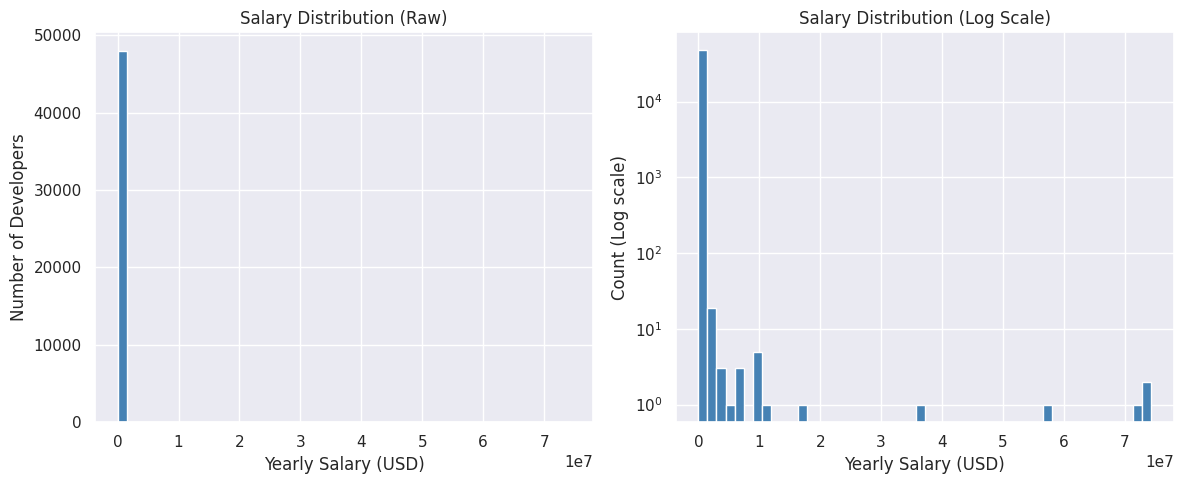


Max salary in dataset: $74,351,432
Min salary in dataset: $1
Median salary: $74,963


In [24]:
# Filter out missing salaries first
df_with_salary = df[df['ConvertedCompYearly'].notna()]

plt.figure(figsize=(12, 5))

# Plot 1: Raw distribution
plt.subplot(1, 2, 1)
plt.hist(df_with_salary['ConvertedCompYearly'], bins=50, color='steelblue', edgecolor='white')
plt.title('Salary Distribution (Raw)')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Developers')

# Plot 2: Log scale to handle extreme outliers
plt.subplot(1, 2, 2)
plt.hist(df_with_salary['ConvertedCompYearly'], bins=50, color='steelblue', edgecolor='white', log=True)
plt.title('Salary Distribution (Log Scale)')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Count (Log scale)')

plt.tight_layout()
plt.show()

print(f"\nMax salary in dataset: ${df_with_salary['ConvertedCompYearly'].max():,.0f}")
print(f"Min salary in dataset: ${df_with_salary['ConvertedCompYearly'].min():,.0f}")
print(f"Median salary: ${df_with_salary['ConvertedCompYearly'].median():,.0f}")

In [27]:
# These are the columns we think will predict salary best
key_columns = [
    'Country',
    'EdLevel',
    'YearsCodePro',
    'Employment',   # Full-time, part-time, freelancer
    'DevType',
    'OrgSize',
    'ConvertedCompYearly'
]

# Check messing values of each of these columns
print("Missing values in key columns:")
print("="*40)
for col in key_columns:
    missing = df[col].isna().sum()
    percent = (missing / len(df)) * 100
    print(f"{col:25s}: {missing:5d} missing ({percent:.1f}%)")

Missing values in key columns:
Country                  :  1211 missing (1.4%)
EdLevel                  :  1211 missing (1.4%)
YearsCodePro             : 23048 missing (25.8%)
Employment               :  1286 missing (1.4%)
DevType                  : 12312 missing (13.8%)
OrgSize                  : 24141 missing (27.1%)
ConvertedCompYearly      : 41165 missing (46.2%)
